# Autoencoder implementation

This notebook implements autoencoder using 1 year hourly T_2M data 

In [19]:
from pathlib import Path
import sys
import importlib
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / 'src' / 'my_ml_zoo').exists():
        repo_root = candidate
        break
else:
    raise RuntimeError('Unable to locate repository root containing src/my_ml_zoo')

src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

importlib.invalidate_caches()
for module_name in [
    'my_ml_zoo.data',
    'my_ml_zoo',
    'my_ml_zoo.data.dataset_config',
    'my_ml_zoo.data.file_discovery',
    'my_ml_zoo.data.xarray_dataset',
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

from my_ml_zoo.data import (
    DatasetConfig,
    discover_variable_files,
    select_variable_file,
    open_variable_dataset,
    infer_file_year,
)

### 1. Define dataset 'IAEVALL03'

In [2]:
config_path = repo_root / 'configs' / 'datasets' / 'IAEVALL03.json'
dataset_config = DatasetConfig.load_from_json(config_path)

### 2. Extract the T_2M data for the year 2002

In [3]:
ds_t2m_2000 = open_variable_dataset(dataset_config, 'T_2M', year=2000)['T_2M']
ds_t2m_2000 = ds_t2m_2000.squeeze('height')

n_time, nx, ny = ds_t2m_2000.shape
print(f'( n_time, nx, ny ) = ({n_time}, {nx}, {ny})')

( n_time, nx, ny ) = (8784, 412, 424)


### 3. Divide the data to:
1. training (70%)
2. validation (15%)
3. test (15%)

the split is none consequtively within each month (to get rid of seasonal bias)

In [4]:
rng = np.random.default_rng(42)

months = ds_t2m_2000["time"].dt.month.values

train_idx = []
val_idx = []
test_idx = []

for month in range(1, 13):
    
    idx_month = np.where(months == month)[0]
    
    idx_month = rng.permutation(idx_month)

    n_curr_month = len(idx_month)

    n_train_curr_month = int(0.70 * n_curr_month)
    n_val_curr_month = int(0.15 * n_curr_month)
    n_test_curr_month = n_curr_month - n_train_curr_month - n_val_curr_month

    train_idx.append(idx_month[:n_train_curr_month])
    val_idx.append(idx_month[n_train_curr_month:n_train_curr_month + n_val_curr_month])
    test_idx.append(idx_month[n_train_curr_month + n_val_curr_month:])

train_idx = np.sort(np.concatenate(train_idx))
val_idx = np.sort(np.concatenate(val_idx))
test_idx = np.sort(np.concatenate(test_idx))

train_da = ds_t2m_2000.isel(time=train_idx)
val_da   = ds_t2m_2000.isel(time=val_idx)
test_da  = ds_t2m_2000.isel(time=test_idx)

print('train da shape:',train_da.shape)
print('val da shape:',val_da.shape)
print('test da shape:',test_da.shape)

train da shape: (6139, 412, 424)
val da shape: (1313, 412, 424)
test da shape: (1332, 412, 424)


### 4. Compute the normalization characteristics on the training data

In [5]:
train_mean = train_da.astype(np.float64).mean().item()
train_std = train_da.astype(np.float64).std().item()

print("train_mean =", train_mean)
print("train_std  =", train_std)

train_mean = 285.0142155784381
train_std  = 10.29710768190146


### 5. Normalize the training, validation and test data using the obtained characteristics

In [6]:
train_norm = (train_da - train_mean) / train_std
val_norm   = (val_da   - train_mean) / train_std
test_norm  = (test_da  - train_mean) / train_std

In [7]:
# validation
print("train norm mean:", train_norm.astype(np.float64).mean().item())
print("train norm std :", train_norm.astype(np.float64).std().item())
print("val   norm mean:", val_norm.astype(np.float64).mean().item())
print("val   norm std :", val_norm.astype(np.float64).std().item())

train norm mean: -5.451027059425876e-07
train norm std : 0.9999999985759511
val   norm mean: 0.00295235601495781
val   norm std : 1.0027945030528522


### 6. Save the data as numpy array

In [8]:
X_train = train_norm.values.astype(np.float32)
X_val   = val_norm.values.astype(np.float32)
X_test  = test_norm.values.astype(np.float32)

## 7. Add the channel dimension 

PyTorch convolution layers expect image-like data in the shape [N, C, H, W]

1. N - batch size
2. C - number of channels
3. H - height
4. W - width

In [9]:
print("before channel dim:")
print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)

X_train = X_train[:, None, :, :]
X_val   = X_val[:, None, :, :]
X_test  = X_test[:, None, :, :]

print("\nafter channel dim:")
print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)

before channel dim:
X_train: (6139, 412, 424) float32
X_val: (1313, 412, 424) float32
X_test: (1332, 412, 424) float32

after channel dim:
X_train: (6139, 1, 412, 424) float32
X_val: (1313, 1, 412, 424) float32
X_test: (1332, 1, 412, 424) float32


## 8. Create simple pytorch dataset

In [10]:
class FullFieldAutoencoderDataset(Dataset):
    def __init__(self, data: np.ndarray):
        if data.ndim != 4:
            raise ValueError(f"Expected shape [N, C, H, W], got {data.shape}")
        self.data = torch.from_numpy(data)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]
    
train_dataset = FullFieldAutoencoderDataset(X_train)
val_dataset   = FullFieldAutoencoderDataset(X_val)
test_dataset  = FullFieldAutoencoderDataset(X_test)

## 9. Create data loaders

In [11]:
# the number of samples passed to the model in one forward/backward pass
batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# num_workers are the number of additional parallell processes to load the data (skip for now)

## 10. Inspect one loaded batch

batch shape: torch.Size([4, 1, 412, 424])
batch dtype: torch.float32
batch min: -3.961245059967041
batch max: 2.8693246841430664
batch mean: 0.21900033950805664
batch std : 0.9489637613296509


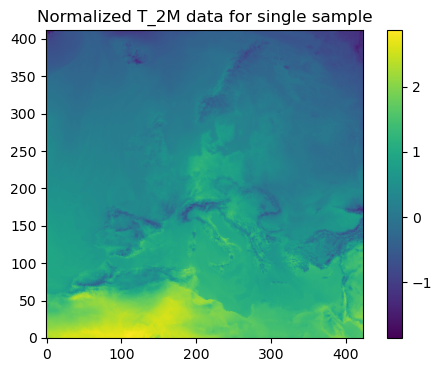

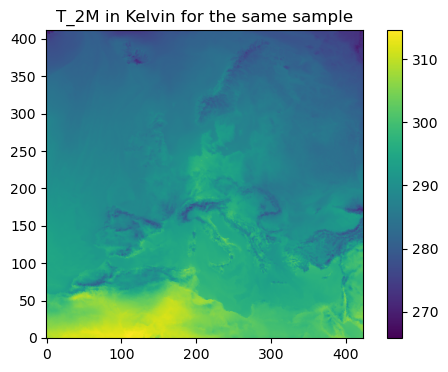

In [12]:
batch = next(iter(train_loader))

# general characteristics
print("batch shape:", batch.shape)
print("batch dtype:", batch.dtype)
print("batch min:", batch.min().item())
print("batch max:", batch.max().item())
print("batch mean:", batch.mean().item())
print("batch std :", batch.std().item())

# 2d plot normalized and in physical space
sample_norm = batch[0, 0].numpy()
sample_phys = sample_norm * train_std + train_mean

plt.figure(figsize=(6, 4))
plt.imshow(sample_norm, origin="lower")
plt.colorbar()
plt.title("Normalized T_2M data for single sample")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(sample_phys, origin="lower")
plt.colorbar()
plt.title("T_2M in Kelvin for the same sample")
plt.show()

In [13]:
# save some split info for the future

split_info = {
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx,
    "train_mean": train_mean,
    "train_std": train_std,
}

## 11. Create first tiny autoencoder architecture 

with matching input and output shapes

In [40]:
# Input:                  1 × 412 × 424
# Conv + ReLU + Pool      8 × 206 × 212
# Conv + ReLU + Pool     16 × 103 × 106
# Conv + ReLU + Pool     32 ×  51 ×  53
# Deconv + ReLU          16 × 103 × 106
# Deconv + ReLU           8 × 206 × 212
# Deconv                  1 × 412 × 424

class SimpleAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16,
                kernel_size=2,
                stride=2,
                output_padding=(1, 0)
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(8, 1, kernel_size=2, stride=2),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

## 12. Test forward propagation

In [41]:
x = next(iter(train_loader))
model = SimpleAutoencoder()
y = model(x)

In [42]:
# check if the shapes are matching

print(x.shape)
print(y.shape)

torch.Size([4, 1, 412, 424])
torch.Size([4, 1, 412, 424])


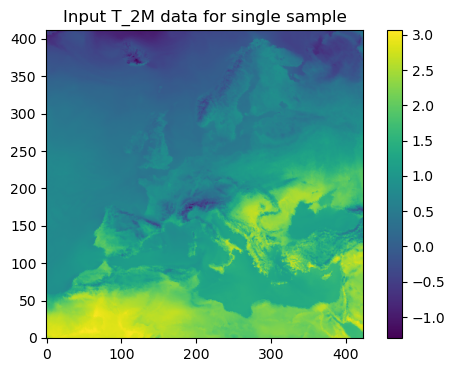

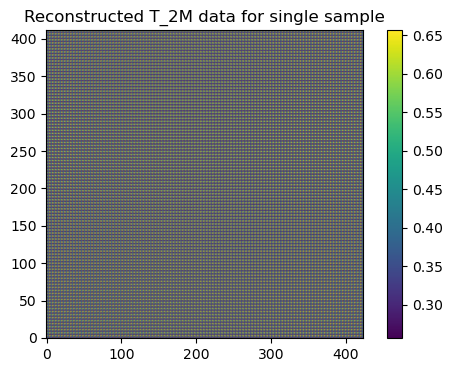

In [43]:
# show that reconstruction is not working yet

plt.figure(figsize=(6, 4))
plt.imshow(x[0,0,:,:].detach().numpy(), origin="lower")
plt.colorbar()
plt.title("Input T_2M data for single sample")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(y[0,0,:,:].detach().numpy(), origin="lower")
plt.colorbar()
plt.title("Reconstructed T_2M data for single sample")
plt.show()

## 13. Check an availability of GPU and create device

In [44]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

True
1
NVIDIA A100-SXM4-40GB


device(type='cuda')

## 14. Upload the model to the device, define MSE loss and optimizer

In [45]:
model = SimpleAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# check the forward propagation on device
batch = next(iter(train_loader)).to(device)
output = model(batch)
loss = criterion(output, batch)

print("input shape :", batch.shape)
print("output shape:", output.shape)
print("initial loss:", loss.item())

input shape : torch.Size([4, 1, 412, 424])
output shape: torch.Size([4, 1, 412, 424])
initial loss: 1.0013197660446167


## 15. First training attempt

In [46]:
num_epochs = 5

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # training
    model.train()
    running_train_loss = 0.0
    n_train_samples = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()

        batch_size_curr = batch.size(0)
        running_train_loss += loss.item() * batch_size_curr
        n_train_samples += batch_size_curr

    epoch_train_loss = running_train_loss / n_train_samples
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0
    n_val_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            output = model(batch)
            loss = criterion(output, batch)

            batch_size_curr = batch.size(0)
            running_val_loss += loss.item() * batch_size_curr
            n_val_samples += batch_size_curr

    epoch_val_loss = running_val_loss / n_val_samples
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss = {epoch_train_loss:.6f} | "
        f"val loss = {epoch_val_loss:.6f}"
    )

Epoch 01/5 | train loss = 0.067682 | val loss = 0.013637
Epoch 02/5 | train loss = 0.012337 | val loss = 0.011254
Epoch 03/5 | train loss = 0.011239 | val loss = 0.010486
Epoch 04/5 | train loss = 0.010597 | val loss = 0.010518
Epoch 05/5 | train loss = 0.010424 | val loss = 0.009829


## 16. Plot loss curves

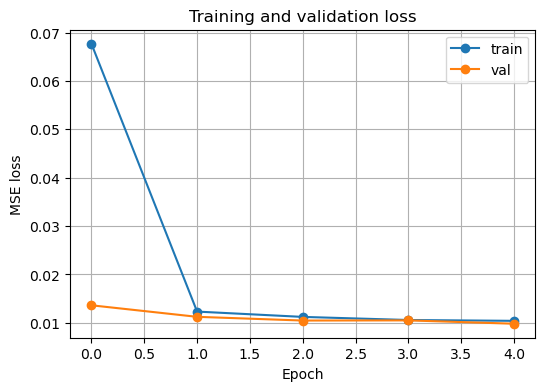

In [47]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o", label="train")
plt.plot(val_losses, marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.grid(True)
plt.legend()
plt.show()

## 17. Inspect reconstructions

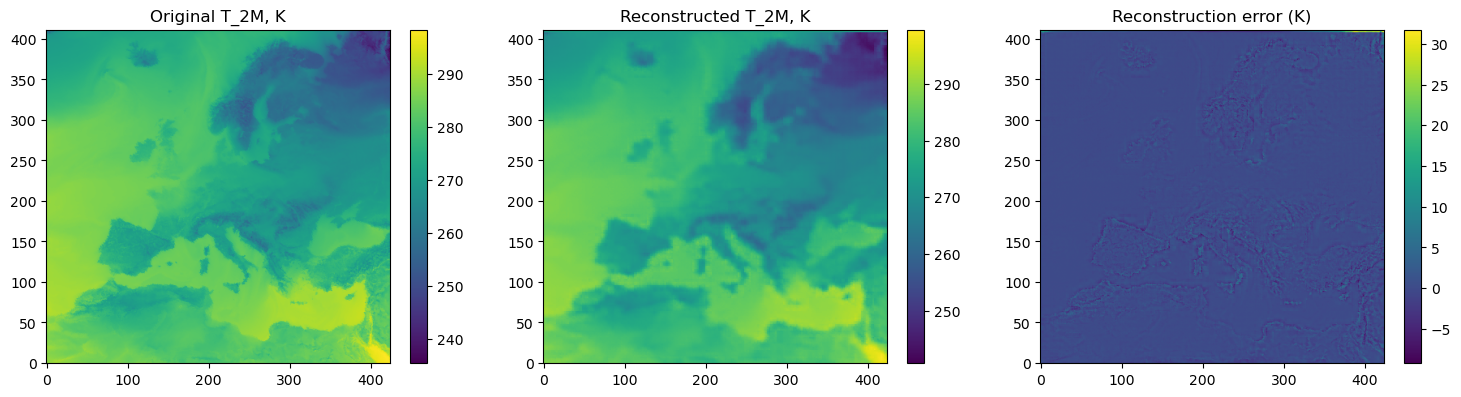

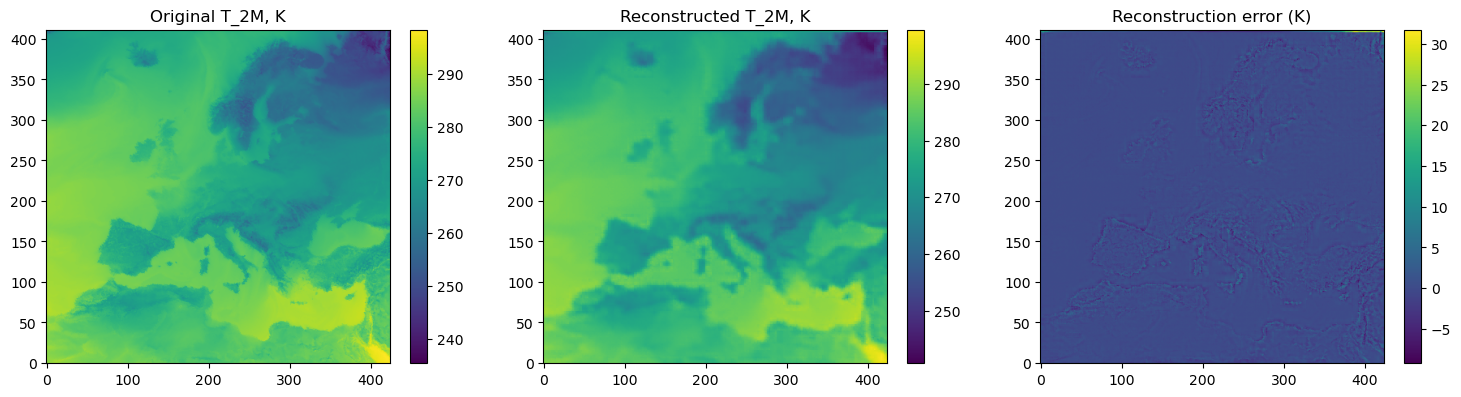

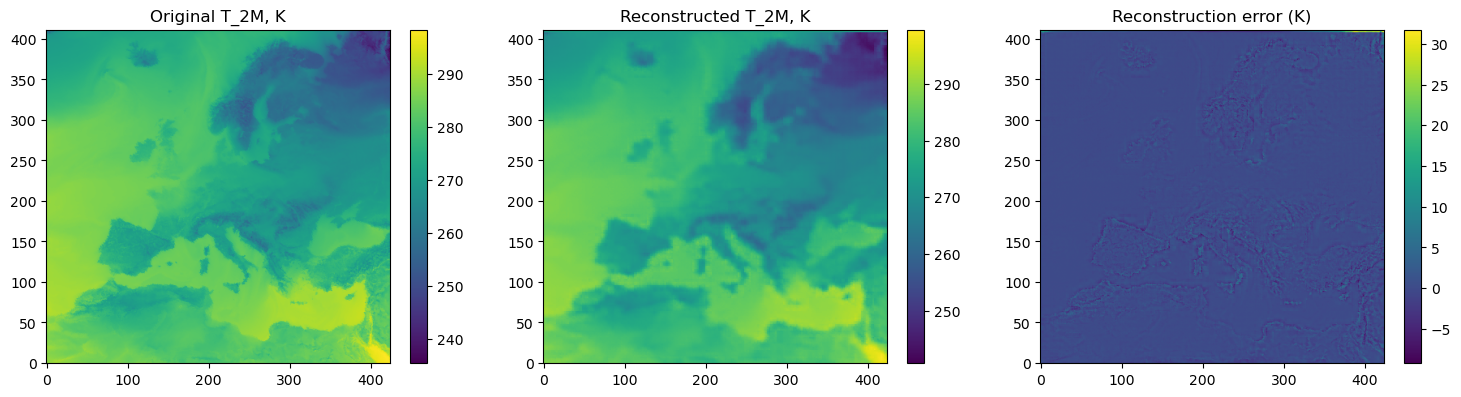

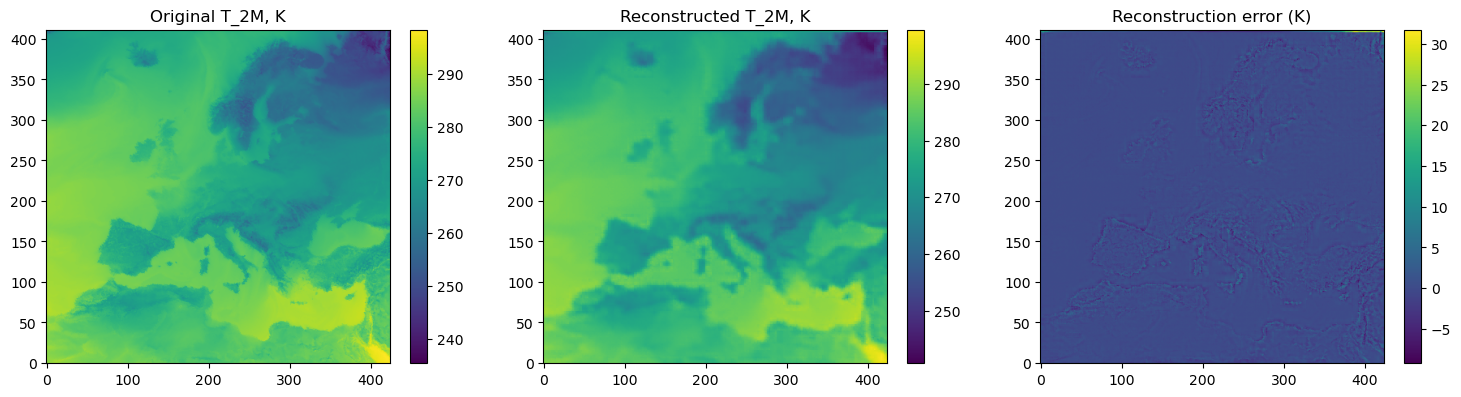

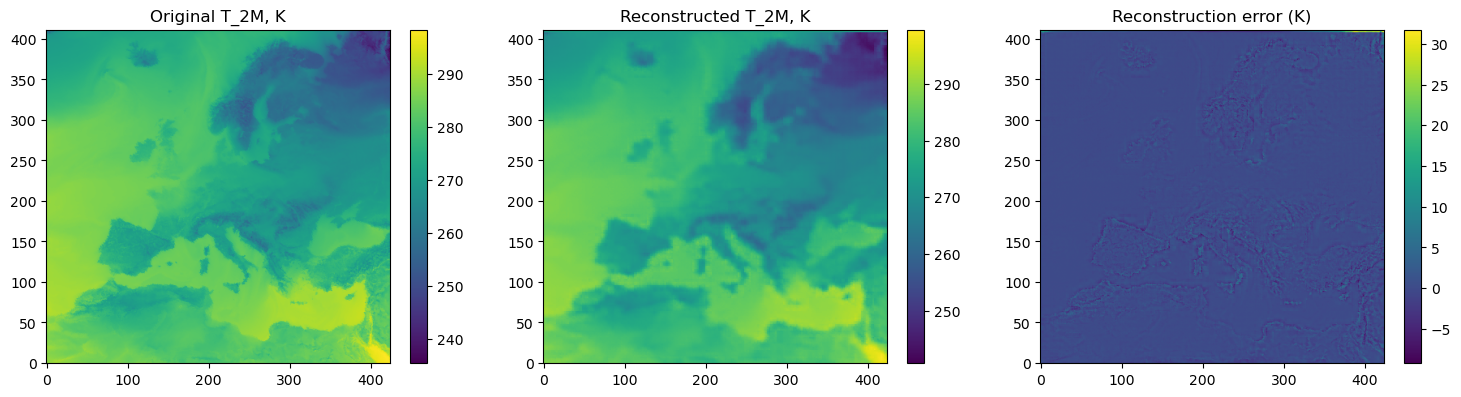

In [51]:
model = model.to(device)
model.eval()

nbatches_show = 5

batches = [next(iter(test_loader)).to(device) for _ in range(nbatches_show)]

with torch.no_grad():
    reconstructions = [model(batch) for batch in batches]

batches_np = [batch.detach().cpu().numpy() for batch in batches]
recons_np = [recon.detach().cpu().numpy() for recon in reconstructions]

for i in range(nbatches_show):
    idx = 0
    x_norm = batches_np[i][idx, 0]
    y_norm = recons_np[i][idx, 0]
    err_norm = y_norm - x_norm

    x_phys = x_norm * train_std + train_mean
    y_phys = y_norm * train_std + train_mean
    err_phys = y_phys - x_phys

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axes[0].imshow(x_phys, origin="lower")
    axes[0].set_title("Original T_2M, K")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(y_phys, origin="lower")
    axes[1].set_title("Reconstructed T_2M, K")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(err_phys, origin="lower")
    axes[2].set_title("Reconstruction error (K)")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()